In [3]:
import os
import json
import xgboost as xgb
import matplotlib.pyplot as plt

In [4]:
model_gcs_path = "gs://ieor4526-final-project-regional/model_output_final/model/model.bst"
local_model_file = "model.bst"

# Download the model file from bucket
!gsutil cp {model_gcs_path} {local_model_file}
print("Model copy complete")

Copying gs://ieor4526-final-project-regional/model_output_final/model/model.bst...
/ [1 files][  1.0 MiB/  1.0 MiB]                                                
Operation completed over 1 objects/1.0 MiB.                                      
Model copy complete


In [6]:
# retrieve feature meta data for mapping back original feature names
feature_metadata_path = "gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_training_data_csv/feat_metadata.json"

!gsutil cp "gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_training_data_csv/feat_metadata.json" "feat_metadata.json"

with open('feat_metadata.json', 'r') as f:
    metadata = json.load(f)

Copying gs://zz3276-ieor4526-bucket/data/4526 final project data/taxi_training_data_csv/feat_metadata.json...
/ [1 files][  8.7 KiB/  8.7 KiB]                                                
Operation completed over 1 objects/8.7 KiB.                                      


In [7]:
metadata

{'ml_attr': {'attrs': {'numeric': [{'idx': 0, 'name': 'trip_distance'},
    {'idx': 1, 'name': 'duration_sec'},
    {'idx': 2, 'name': 'avg_speed_mph'},
    {'idx': 3, 'name': 'passenger_count'},
    {'idx': 4, 'name': 'pickup_hour_sin'},
    {'idx': 5, 'name': 'pickup_hour_cos'}],
   'binary': [{'idx': 6, 'name': 'PU_Borough_onehot_Manhattan'},
    {'idx': 7, 'name': 'PU_Borough_onehot_Queens'},
    {'idx': 8, 'name': 'PU_Borough_onehot_Brooklyn'},
    {'idx': 9, 'name': 'PU_Borough_onehot_Bronx'},
    {'idx': 10, 'name': 'PU_Borough_onehot_Unknown'},
    {'idx': 11, 'name': 'PU_Borough_onehot_N/A'},
    {'idx': 12, 'name': 'PU_Borough_onehot_Staten Island'},
    {'idx': 13, 'name': 'PU_service_zone_onehot_Yellow Zone'},
    {'idx': 14, 'name': 'PU_service_zone_onehot_Airports'},
    {'idx': 15, 'name': 'PU_service_zone_onehot_Boro Zone'},
    {'idx': 16, 'name': 'PU_service_zone_onehot_N/A'},
    {'idx': 17, 'name': 'DO_Borough_onehot_Manhattan'},
    {'idx': 18, 'name': 'DO_Borough_

In [8]:
all_attrs = metadata['ml_attr']['attrs']['numeric'] + metadata['ml_attr']['attrs']['binary']
all_attrs_sorted = sorted(all_attrs, key=lambda x: x['idx'])

feature_names = [attr['name'] for attr in all_attrs_sorted]

/tmp/ipykernel_8459/3150972677.py:2: UserWarning: [22:30:15] WARNING: /workspace/src/c_api/c_api.cc:1511: Unknown file format: `bst`. Using UBJSON (`ubj`) as a guess.
  booster.load_model("model.bst")


<Figure size 1000x800 with 0 Axes>

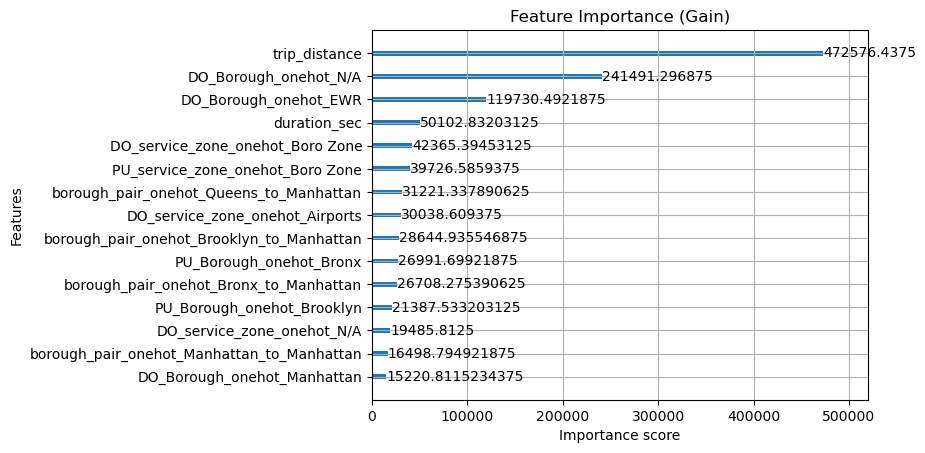

In [10]:
booster = xgb.Booster()
booster.load_model("model.bst")

# 2. Manually set the feature names from your metadata list
# (Assuming you still have 'feature_names' defined from the JSON step)
booster.feature_names = feature_names

# 3. Plot using the booster directly
plt.figure(figsize=(10, 8))
xgb.plot_importance(booster, importance_type='gain', max_num_features=15)
plt.title("Feature Importance (Gain)")
plt.show()